### **Visualization of Images**

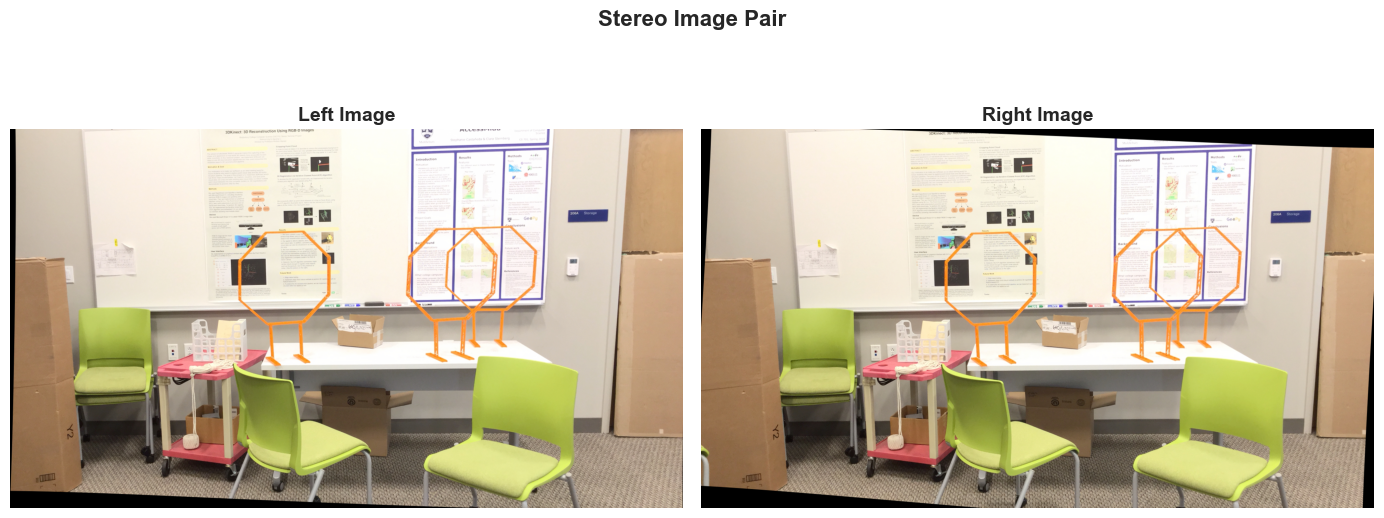

In [4]:
# Cell 1: Import libraries and load images
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from matplotlib import cm
from tqdm.notebook import tqdm
import time
# Set the style for more aesthetic plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12

# Load the stereo images
left_img = cv2.imread('left.png')
right_img = cv2.imread('right.png')

# Check if images loaded correctly
if left_img is None or right_img is None:
    print("Error: Could not load images")
    exit()

# Convert to grayscale for disparity calculation
left_gray = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY) if len(left_img.shape) == 3 else left_img
right_gray = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY) if len(right_img.shape) == 3 else right_img

# Convert BGR to RGB for matplotlib
left_rgb = cv2.cvtColor(left_img, cv2.COLOR_BGR2RGB) if len(left_img.shape) == 3 else np.stack([left_img]*3, axis=2)
right_rgb = cv2.cvtColor(right_img, cv2.COLOR_BGR2RGB) if len(right_img.shape) == 3 else np.stack([right_img]*3, axis=2)

# Visualize the input stereo images
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(left_rgb)
axes[0].set_title('Left Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(right_rgb)
axes[1].set_title('Right Image', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.suptitle('Stereo Image Pair', fontsize=16, fontweight='bold', y=0.98)
plt.subplots_adjust(top=0.9)
plt.show()


### **Built-In Implementation**

In [3]:
# Create a stereo matcher object - StereoBM (Block Matching)
print("Computing disparity map using Block Matching algorithm...")

# Create StereoBM object
stereo_bm = cv2.StereoBM_create(numDisparities=16*10, blockSize=15)

# Compute the disparity map
disparity_bm = stereo_bm.compute(left_gray, right_gray)

# Create StereoSGBM object (Semi-Global Block Matching) for better results
stereo_sgbm = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=16*10,  # must be divisible by 16
    blockSize=5,
    P1=8 * 3 * 5**2,  # Controls disparity smoothness
    P2=32 * 3 * 5**2,  # P2 > P1 always
    disp12MaxDiff=1,
    uniquenessRatio=15,
    speckleWindowSize=100,
    speckleRange=2,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)

# Compute the disparity map with SGBM
disparity_sgbm = stereo_sgbm.compute(left_gray, right_gray)
print("Disparity computation complete!")

Computing disparity map using Block Matching algorithm...
Disparity computation complete!


### **Visualization of the Result**

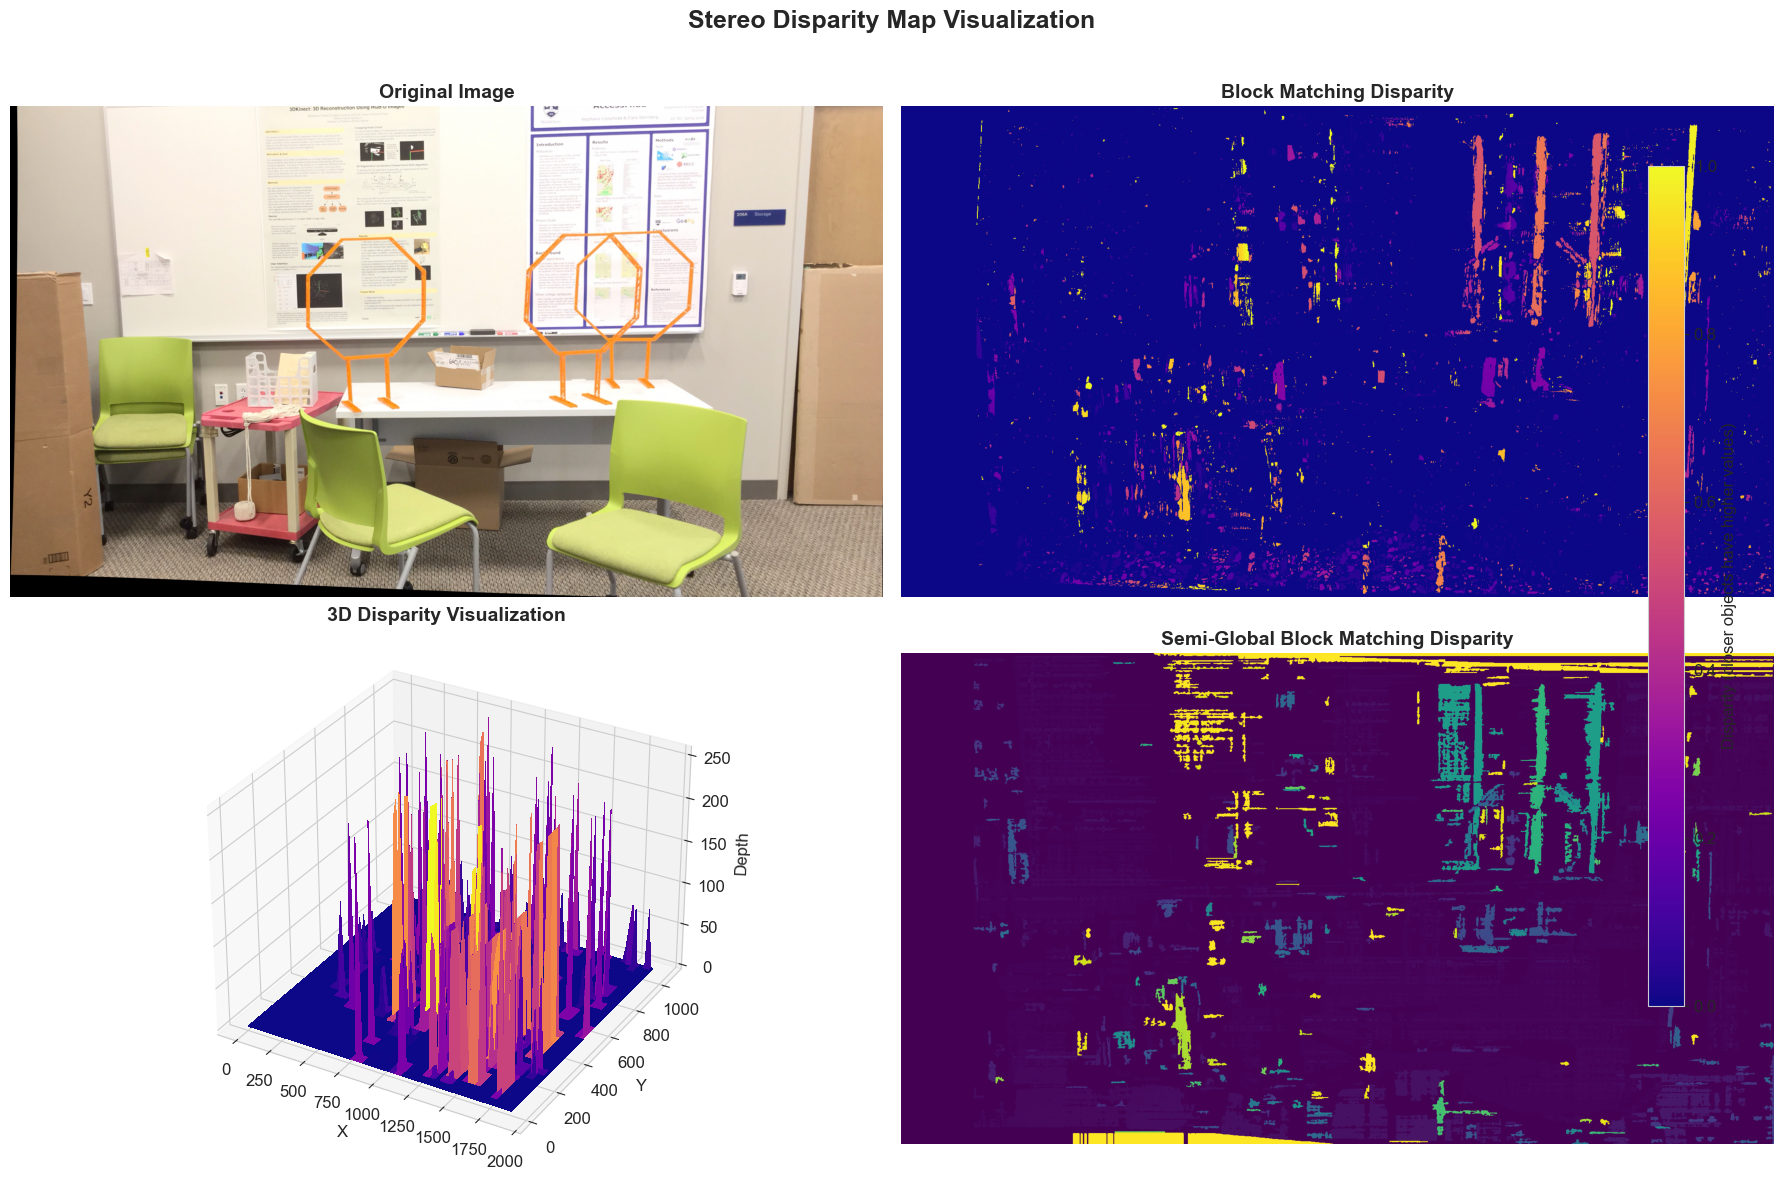

In [4]:
def visualize_disparity(disparity, title, colormap=cm.jet):
    # Normalize the disparity for visualization
    disp_normalized = cv2.normalize(disparity, None, alpha=0, beta=255, 
                                  norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    # Apply a colormap
    disp_colored = colormap(disp_normalized)
    
    # Remove the alpha channel
    disp_colored = disp_colored[:, :, :3]
    
    return disp_colored, disp_normalized

# Normalize and color the disparity maps
disp_bm_colored, disp_bm_norm = visualize_disparity(disparity_bm, "Block Matching", cm.plasma)
disp_sgbm_colored, disp_sgbm_norm = visualize_disparity(disparity_sgbm, "Semi-Global Block Matching", cm.viridis)

# Create a figure for visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Original left image
axes[0, 0].imshow(left_rgb)
axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# Block Matching Disparity
axes[0, 1].imshow(disp_bm_colored)
axes[0, 1].set_title('Block Matching Disparity', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

# 3D visualization using Block Matching
x = np.arange(0, left_gray.shape[1])
y = np.arange(0, left_gray.shape[0])
x, y = np.meshgrid(x, y)
axes[1, 0].remove()
ax3d = fig.add_subplot(2, 2, 3, projection='3d')
# Downsample for better performance
stride = 20
ax3d.plot_surface(x[::stride, ::stride], 
                  y[::stride, ::stride], 
                  disp_bm_norm[::stride, ::stride], 
                  cmap=cm.plasma,
                  linewidth=0,
                  antialiased=False)
ax3d.set_title('3D Disparity Visualization', fontsize=14, fontweight='bold')
ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Depth')

# Semi-Global Block Matching Disparity (better quality)
axes[1, 1].imshow(disp_sgbm_colored)
axes[1, 1].set_title('Semi-Global Block Matching Disparity', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.suptitle('Stereo Disparity Map Visualization', fontsize=18, fontweight='bold', y=0.98)
plt.subplots_adjust(top=0.92)

# Add a colorbar for reference
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cm.plasma)
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Disparity (closer objects have higher values)', fontsize=12)
plt.show()

### **Anaglyph 3D Visualization**

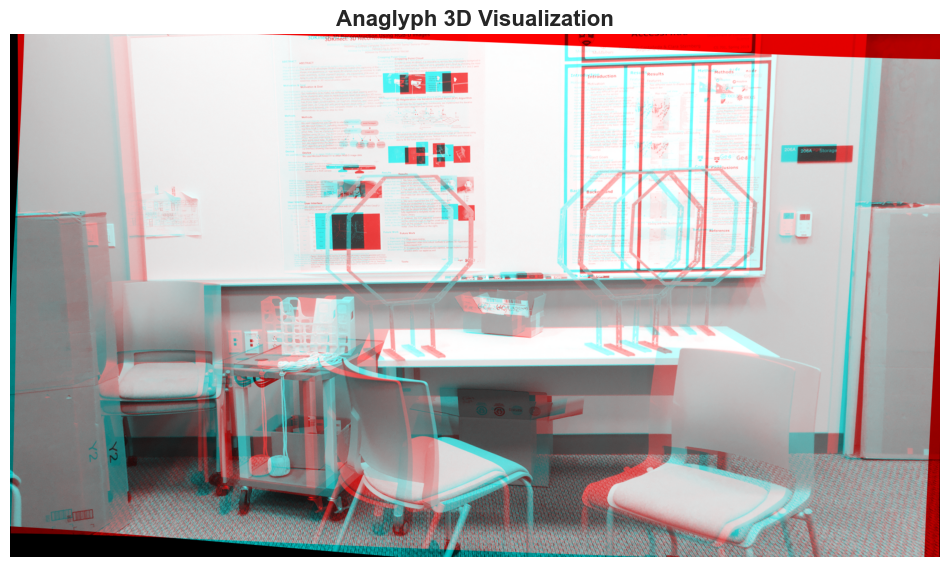

In [5]:
def create_anaglyph(left_img, right_img):
    # Create an anaglyph image (red-cyan 3D)
    anaglyph = np.zeros_like(left_rgb)
    
    # Red channel from left image
    anaglyph[:, :, 0] = left_gray
    
    # Green and blue channels from right image
    anaglyph[:, :, 1] = right_gray
    anaglyph[:, :, 2] = right_gray
    
    return anaglyph

anaglyph = create_anaglyph(left_gray, right_gray)

plt.figure(figsize=(12, 8))
plt.imshow(anaglyph)
plt.title('Anaglyph 3D Visualization', 
          fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()


### **Implementation from Scratch**

In [ ]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt

def preprocess_stereo_images(left_img, right_img):
    # Convert to grayscale if images are colored
    if len(left_img.shape) == 3:
        left_gray = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
        right_gray = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)
    else:
        left_gray = left_img.copy()
        right_gray = right_img.copy()
    
    # Apply Gaussian blur to reduce noise
    left_blur = cv2.GaussianBlur(left_gray, (5, 5), 0)
    right_blur = cv2.GaussianBlur(right_gray, (5, 5), 0)
    
    # Apply histogram equalization to improve contrast
    left_eq = cv2.equalizeHist(left_blur)
    right_eq = cv2.equalizeHist(right_blur)
    
    return left_eq, right_eq

def compute_census_transform(image, window_size=5):
    # Ensure window size is odd
    if window_size % 2 == 0:
        window_size += 1
    
    height, width = image.shape
    half_window = window_size // 2
    
    # Initialize census transform array with uint64 to store bit strings
    # (we'll use a more efficient representation than storing full bit strings)
    census = np.zeros((height, width), dtype=np.uint64)
    
    # Pad image to handle border pixels
    padded = cv2.copyMakeBorder(image, half_window, half_window, half_window, half_window,
                               cv2.BORDER_CONSTANT, value=0)
    
    # For each pixel in the image
    for y in range(height):
        for x in range(width):
            # Get center pixel value
            center_val = padded[y + half_window, x + half_window]
            bit_string = 0
            bit_position = 0
            
            # Compare with neighbors
            for wy in range(window_size):
                for wx in range(window_size):
                    # Skip the center pixel
                    if wy == half_window and wx == half_window:
                        continue
                    
                    # Get neighbor pixel value
                    neighbor_val = padded[y + wy, x + wx]
                    
                    # Compare and set bit
                    if neighbor_val < center_val:
                        bit_string |= (1 << bit_position)
                    
                    # Move to next bit position
                    bit_position += 1
                    
                    # Avoid overflow (use max 64 bits)
                    if bit_position >= 64:
                        break
            
            # Store the census value
            census[y, x] = bit_string
            
    return census

def hamming_distance(a, b):
    # XOR gives 1 for bits that differ
    xor_result = a ^ b
    
    # Count the number of set bits (1s)
    # This is a popcount operation
    count = 0
    while xor_result:
        count += xor_result & 1
        xor_result >>= 1
    
    return count

def calculate_disparity_census(left_img, right_img, window_size=9, max_disparity=64):

    # Apply Census Transform to both images
    print("Computing Census Transform...")
    left_census = compute_census_transform(left_img, window_size=5)  # Smaller window for census transform
    right_census = compute_census_transform(right_img, window_size=5)
    
    # Get image dimensions
    height, width = left_img.shape
    
    # Initialize disparity map
    disparity_map = np.zeros((height, width), dtype=np.float32)
    
    # Calculate half window size for cost aggregation
    half_window = window_size // 2
    
    # Pad images to handle border pixels
    left_padded = np.pad(left_census, ((half_window, half_window), (half_window, half_window)), 
                         mode='constant', constant_values=0)
    right_padded = np.pad(right_census, ((half_window, half_window), (half_window, half_window)),
                          mode='constant', constant_values=0)
    
    # For each pixel in the left image
    start_time = time.time()
    for y in range(height):
        # Print progress
        if y % max(1, (height // 10)) == 0:
            percent_done = y / height * 100
            elapsed = time.time() - start_time
            print(f"Processing: {percent_done:.1f}% done, elapsed time: {elapsed:.1f}s")
            
        for x in range(max_disparity, width):
            best_disparity = 0
            min_cost = float('inf')
            
            # Compare with right image at different disparities
            for d in range(max_disparity + 1):
                cost = 0
                
                # Aggregate costs over window
                for wy in range(-half_window, half_window + 1):
                    for wx in range(-half_window, half_window + 1):
                        # Get census values
                        left_val = left_padded[y + half_window + wy, x + half_window + wx]
                        right_val = right_padded[y + half_window + wy, x + half_window + wx - d]
                        
                        # Add Hamming distance to cost
                        cost += hamming_distance(left_val, right_val)
                
                # Update if this disparity gives a better match
                if cost < min_cost:
                    min_cost = cost
                    best_disparity = d
            
            # Save the best disparity value
            disparity_map[y, x] = best_disparity
    
    # Fill in the border regions (where disparity couldn't be calculated)
    # Simple approach: copy nearest valid disparity
    for y in range(height):
        for x in range(min(max_disparity, width)):
            if x == 0:
                # For leftmost column, use the first valid column
                disparity_map[y, x] = disparity_map[y, max_disparity]
            else:
                # For other border columns, use the nearest valid column
                disparity_map[y, x] = disparity_map[y, max_disparity]
    
    # Normalize disparity map for visualization
    if np.max(disparity_map) > 0:
        disparity_map = (disparity_map * 255.0 / max_disparity).astype(np.uint8)
    
    return disparity_map

def calculate_disparity_sad(left_img, right_img, window_size=15, max_disparity=64):
    # Ensure window size is odd
    if window_size % 2 == 0:
        window_size += 1
    
    # Get image dimensions
    height, width = left_img.shape
    
    # Initialize disparity map
    disparity_map = np.zeros((height, width), dtype=np.float32)
    
    # Calculate half window size for neighborhoods
    half_window = window_size // 2
    
    # Pad images to handle border pixels
    left_padded = cv2.copyMakeBorder(left_img, half_window, half_window, half_window, half_window, 
                                     cv2.BORDER_CONSTANT, value=0)
    right_padded = cv2.copyMakeBorder(right_img, half_window, half_window, half_window, half_window,
                                      cv2.BORDER_CONSTANT, value=0)
    
    # For each pixel in the left image (with padding consideration)
    start_time = time.time()
    for y in range(half_window, height + half_window):
        # Print progress every 10% of rows
        if y % max(1, (height // 10)) == 0:
            percent_done = (y - half_window) / height * 100
            elapsed = time.time() - start_time
            print(f"Processing: {percent_done:.1f}% done, elapsed time: {elapsed:.1f}s")
            
        for x in range(half_window + max_disparity, width + half_window):
            best_disparity = 0
            min_cost = float('inf')
            
            # Left image block centered at (y, x)
            left_block = left_padded[y - half_window:y + half_window + 1, 
                                     x - half_window:x + half_window + 1]
            
            # Compare with right image blocks at different disparities
            for d in range(max_disparity + 1):
                # Right image block centered at (y, x-d)
                right_block = right_padded[y - half_window:y + half_window + 1, 
                                           x - d - half_window:x - d + half_window + 1]
                
                # Calculate Sum of Absolute Differences (SAD)
                cost = np.sum(np.abs(left_block.astype(np.float32) - right_block.astype(np.float32)))
                
                # Update if this disparity gives a better match
                if cost < min_cost:
                    min_cost = cost
                    best_disparity = d
            
            # Save the best disparity value
            disparity_map[y - half_window, x - half_window] = best_disparity
    
    # Fill in the border regions (where disparity couldn't be calculated)
    for y in range(height):
        for x in range(min(max_disparity, width)):
            if x == 0:
                disparity_map[y, x] = disparity_map[y, max_disparity]
            else:
                disparity_map[y, x] = disparity_map[y, x+1]
    
    # Normalize disparity map
    if np.max(disparity_map) > 0:
        disparity_map = (disparity_map * 255.0 / max_disparity).astype(np.uint8)
    
    return disparity_map

def post_process_disparity(disparity_map, min_disparity=0, kernel_size=3):
    # Create a mask for valid disparity values
    valid_mask = disparity_map > min_disparity
    
    # Apply median filter to remove outliers
    filtered = cv2.medianBlur(disparity_map, kernel_size)
    
    # Copy valid filtered values
    refined_disparity = disparity_map.copy()
    refined_disparity[valid_mask] = filtered[valid_mask]
    
    # Fill invalid regions using inpainting
    if np.sum(~valid_mask) > 0:
        refined_disparity = cv2.inpaint(
            refined_disparity, 
            (~valid_mask).astype(np.uint8), 
            3, 
            cv2.INPAINT_TELEA
        )
    
    # Apply bilateral filter to smooth while preserving edges
    refined_disparity = cv2.bilateralFilter(
        refined_disparity.astype(np.float32),
        d=5,  # Diameter of each pixel neighborhood
        sigmaColor=50,  # Filter sigma in color space
        sigmaSpace=5  # Filter sigma in coordinate space
    ).astype(np.uint8)
    
    return refined_disparity

def stereo_matching_from_scratch(left_img, right_img, method='census', 
                                window_size=15, max_disparity=64, post_process=True):
    # Preprocess images
    print("Preprocessing images...")
    left_processed, right_processed = preprocess_stereo_images(left_img, right_img)
    
    # Calculate disparity map based on selected method
    if method == 'census':
        print(f"Computing disparity map using Census Transform (window_size={window_size}, max_disparity={max_disparity})...")
        disparity_map = calculate_disparity_census(
            left_processed, right_processed, window_size, max_disparity)
    else:  # Default to SAD
        print(f"Computing disparity map using SAD (window_size={window_size}, max_disparity={max_disparity})...")
        disparity_map = calculate_disparity_sad(
            left_processed, right_processed, window_size, max_disparity)
    
    # Post-process disparity map
    if post_process:
        print("Post-processing disparity map...")
        disparity_map = post_process_disparity(disparity_map)
    
    return disparity_map

def compute_depth_map(disparity_map, focal_length=3740, baseline=160):
    # Avoid division by zero
    valid_disparity = disparity_map.copy()
    valid_disparity[valid_disparity < 1] = 1
    
    # Convert disparity to depth using the formula: depth = (focal_length * baseline) / disparity
    depth_map = (focal_length * baseline) / valid_disparity
    
    return depth_map

def visualize_results(left_img, right_img, disparity_map, depth_map=None):
    plt.figure(figsize=(15, 10))
    
    # Plot left image
    plt.subplot(221)
    plt.title('Left Image')
    plt.imshow(left_img, cmap='gray')
    plt.axis('off')
    
    # Plot right image
    plt.subplot(222)
    plt.title('Right Image')
    plt.imshow(right_img, cmap='gray')
    plt.axis('off')
    
    # Plot disparity map
    plt.subplot(223)
    plt.title('Disparity Map')
    plt.imshow(disparity_map, cmap='jet')
    plt.colorbar(shrink=0.5)
    plt.axis('off')
    
    # Plot depth map if available
    if depth_map is not None:
        plt.subplot(224)
        plt.title('Depth Map')
        # Limit depth range for better visualization
        max_depth = np.percentile(depth_map, 95)  # Use 95th percentile to avoid outlier influence
        plt.imshow(np.clip(depth_map, 0, max_depth), cmap='viridis_r')
        plt.colorbar(shrink=0.5)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Load stereo images
left_img = cv2.imread('left.png')
right_img = cv2.imread('right.png')

if left_img is None or right_img is None:
    print("Error: Could not load images. Please check file paths.")
    exit()

# Convert images to RGB for visualization
left_rgb = cv2.cvtColor(left_img, cv2.COLOR_BGR2RGB)
right_rgb = cv2.cvtColor(right_img, cv2.COLOR_BGR2RGB)

# Convert to grayscale for disparity computation
left_gray = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

# Calculate disparity using the built-in function (for comparison)
print("Computing disparity map using OpenCV's StereoBM...")
stereo_bm = cv2.StereoBM_create(numDisparities=160, blockSize=15)
disparity_builtin = stereo_bm.compute(left_gray, right_gray)

# For faster execution, resize images
scale_factor = 0.25  # Process at 25% of original size
left_small = cv2.resize(left_gray, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)
right_small = cv2.resize(right_gray, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)

# Compute disparity map from scratch
print("Computing disparity map from scratch (this may take several minutes)...")
print(f"Processing at {scale_factor*100:.0f}% of original resolution for speed")

disparity_scratch_small = stereo_matching_from_scratch(
    left_small, right_small,
    method='sad',  # Options: 'sad' or 'census'
    window_size=7,  # Block size (smaller for reduced image)
    max_disparity=32,  # Maximum disparity to check
    post_process=True  # Apply post-processing
)

# Resize back to original size
disparity_scratch = cv2.resize(disparity_scratch_small, (left_gray.shape[1], left_gray.shape[0]), 
                              interpolation=cv2.INTER_LINEAR)
# Scale the disparity values to account for the resize
disparity_scratch = disparity_scratch * (1.0/scale_factor)

Computing disparity map using OpenCV's StereoBM...
Computing disparity map from scratch (this may take several minutes)...
Processing at 25% of original resolution for speed
Preprocessing images...
Computing disparity map using SAD (window_size=7, max_disparity=32)...
Processing: 8.9% done, elapsed time: 5.6s
Processing: 18.9% done, elapsed time: 12.2s
Processing: 28.9% done, elapsed time: 19.1s
Processing: 38.9% done, elapsed time: 27.2s
Processing: 48.9% done, elapsed time: 32.6s
Processing: 58.9% done, elapsed time: 39.5s
Processing: 68.9% done, elapsed time: 45.8s
Processing: 78.9% done, elapsed time: 50.4s
Processing: 88.9% done, elapsed time: 55.4s
Processing: 98.9% done, elapsed time: 62.6s
Post-processing disparity map...


### **Visualization of the Results**

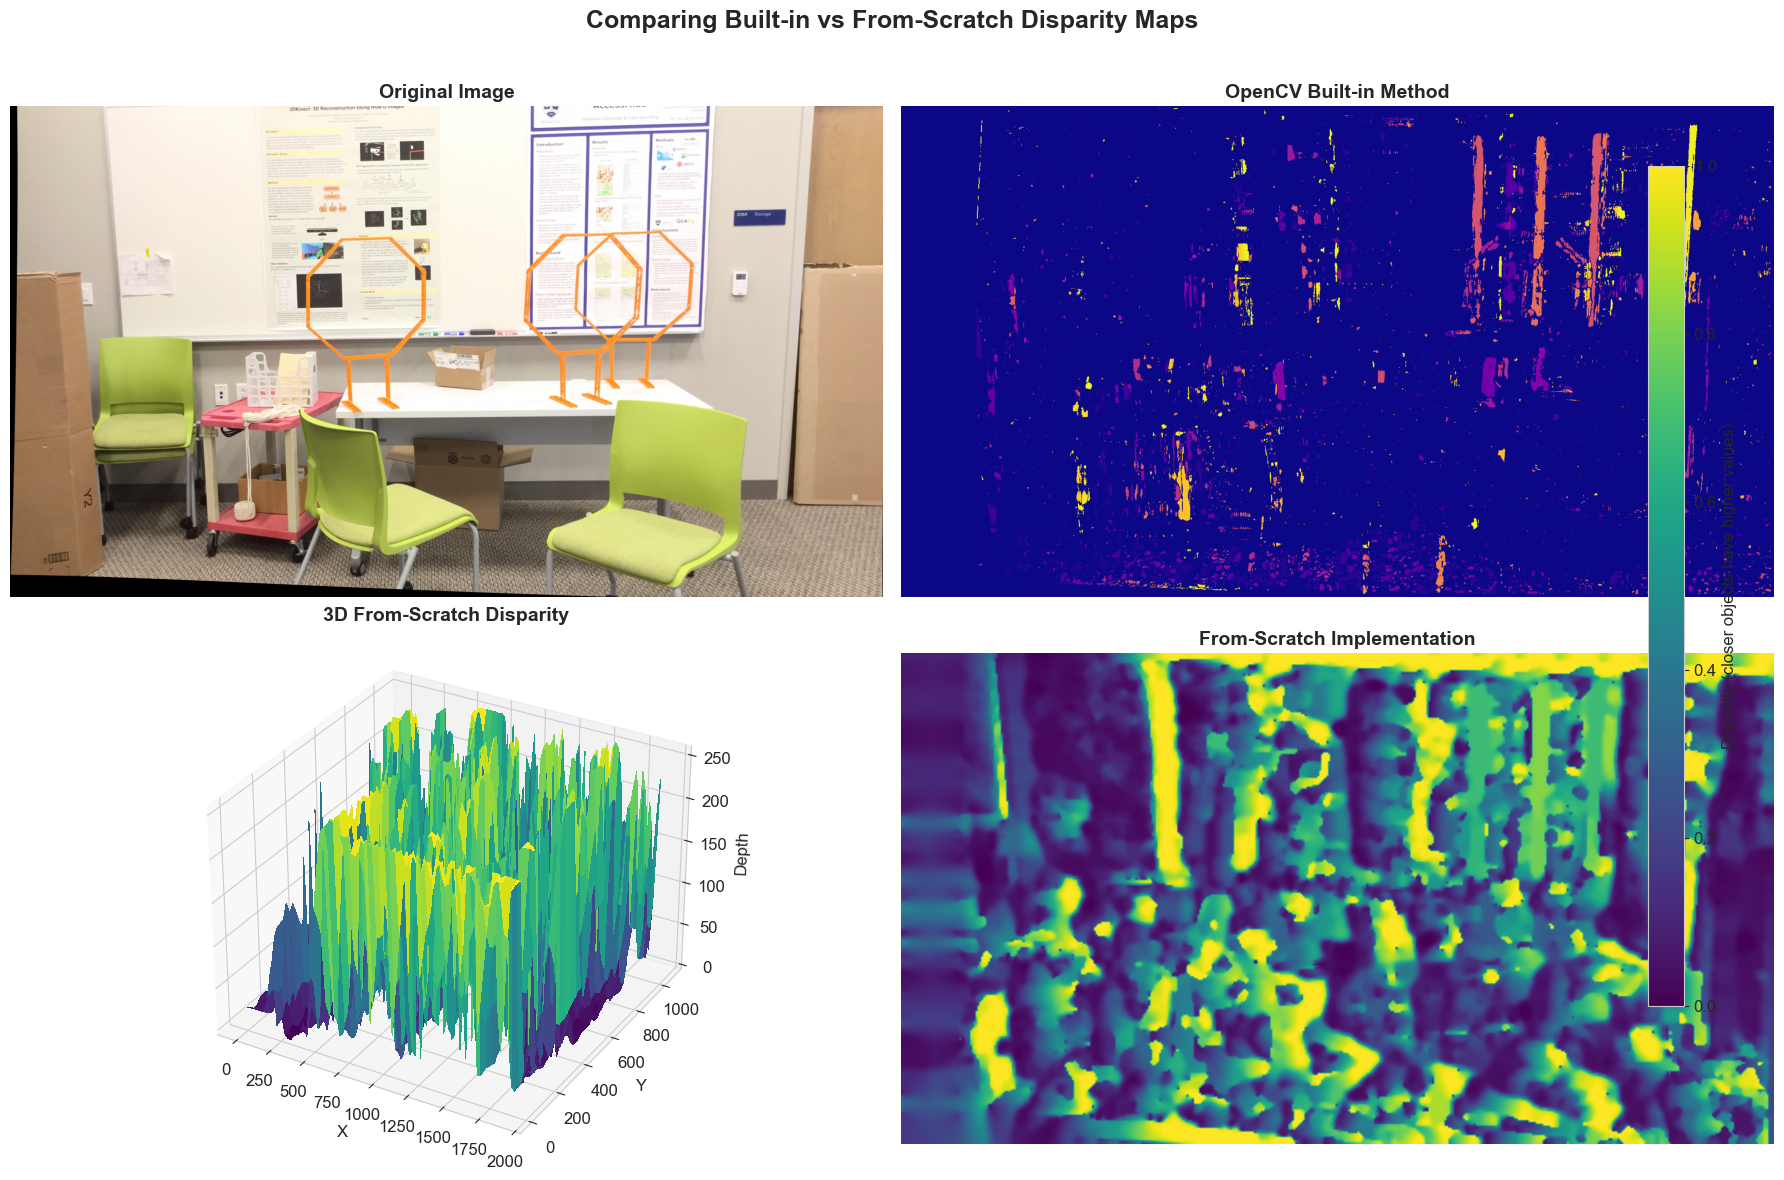

In [5]:
# Function to create aesthetic disparity visualization
def visualize_disparity(disparity, title, colormap=cm.jet):
    # Normalize the disparity for visualization
    if disparity.dtype != np.uint8:
        disp_normalized = cv2.normalize(disparity, None, alpha=0, beta=255, 
                                      norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    else:
        disp_normalized = disparity.copy()
    
    # Apply a colormap
    disp_colored = colormap(disp_normalized)
    
    # Remove the alpha channel
    disp_colored = disp_colored[:, :, :3]
    
    return disp_colored, disp_normalized

# Normalize and color the disparity maps
disp_builtin_colored, disp_builtin_norm = visualize_disparity(disparity_builtin, "Built-in Method", cm.plasma)
disp_scratch_colored, disp_scratch_norm = visualize_disparity(disparity_scratch, "From-Scratch Method", cm.viridis)

# Create a figure for visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Original left image
axes[0, 0].imshow(left_rgb)
axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# Built-in method disparity
axes[0, 1].imshow(disp_builtin_colored)
axes[0, 1].set_title('OpenCV Built-in Method', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

# 3D visualization using from-scratch disparity
x = np.arange(0, disparity_scratch.shape[1])
y = np.arange(0, disparity_scratch.shape[0])
x, y = np.meshgrid(x, y)
axes[1, 0].remove()
ax3d = fig.add_subplot(2, 2, 3, projection='3d')
# Downsample for better performance
stride = 20
ax3d.plot_surface(x[::stride, ::stride], 
                  y[::stride, ::stride], 
                  disp_scratch_norm[::stride, ::stride], 
                  cmap=cm.viridis,
                  linewidth=0,
                  antialiased=False)
ax3d.set_title('3D From-Scratch Disparity', fontsize=14, fontweight='bold')
ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Depth')

# From-scratch method disparity
axes[1, 1].imshow(disp_scratch_colored)
axes[1, 1].set_title('From-Scratch Implementation', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.suptitle('Comparing Built-in vs From-Scratch Disparity Maps', fontsize=18, fontweight='bold', y=0.98)
plt.subplots_adjust(top=0.92)

# Add a colorbar for reference
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cm.viridis)
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Disparity (closer objects have higher values)', fontsize=12)

plt.show()

### **Anaglyph 3D Visualization**

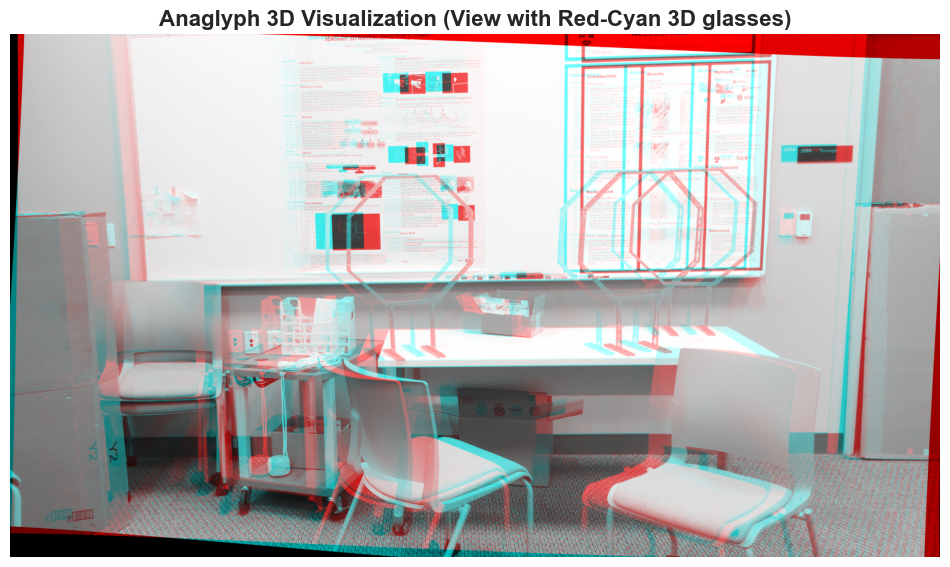

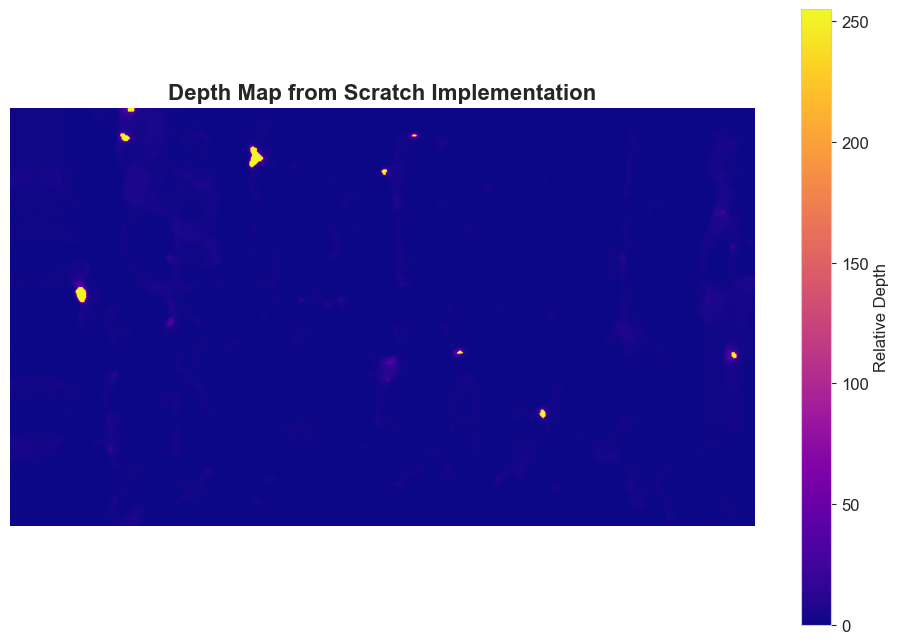

In [6]:
def create_anaglyph(left_img, right_img):
    # Create an anaglyph image (red-cyan 3D)
    anaglyph = np.zeros_like(left_rgb)
    
    # Red channel from left image
    anaglyph[:, :, 0] = left_gray
    
    # Green and blue channels from right image
    anaglyph[:, :, 1] = right_gray
    anaglyph[:, :, 2] = right_gray
    
    return anaglyph

anaglyph = create_anaglyph(left_gray, right_gray)

plt.figure(figsize=(12, 8))
plt.imshow(anaglyph)
plt.title('Anaglyph 3D Visualization (View with Red-Cyan 3D glasses)', 
          fontsize=16, fontweight='bold')
plt.axis('off')
plt.savefig('anaglyph_3d.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: Create depth map visualization using from-scratch disparity
# (this converts disparity to approximate depth values)
def disparity_to_depth(disparity, baseline=0.1, focal_length=500):
    # Convert disparity to depth using the formula: depth = baseline * focal_length / disparity
    # Add a small epsilon to avoid division by zero
    epsilon = 0.1
    depth = baseline * focal_length / (disparity + epsilon)
    # Clip to reasonable values
    depth = np.clip(depth, 0, 100)
    return depth

# Calculate depth map
depth_map = disparity_to_depth(disparity_scratch)
# Normalize for visualization
depth_norm = cv2.normalize(depth_map, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(12, 8))
plt.imshow(depth_norm, cmap='plasma')
plt.colorbar(label='Relative Depth')
plt.title('Depth Map from Scratch Implementation', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()


### **Side By Side Comparison**

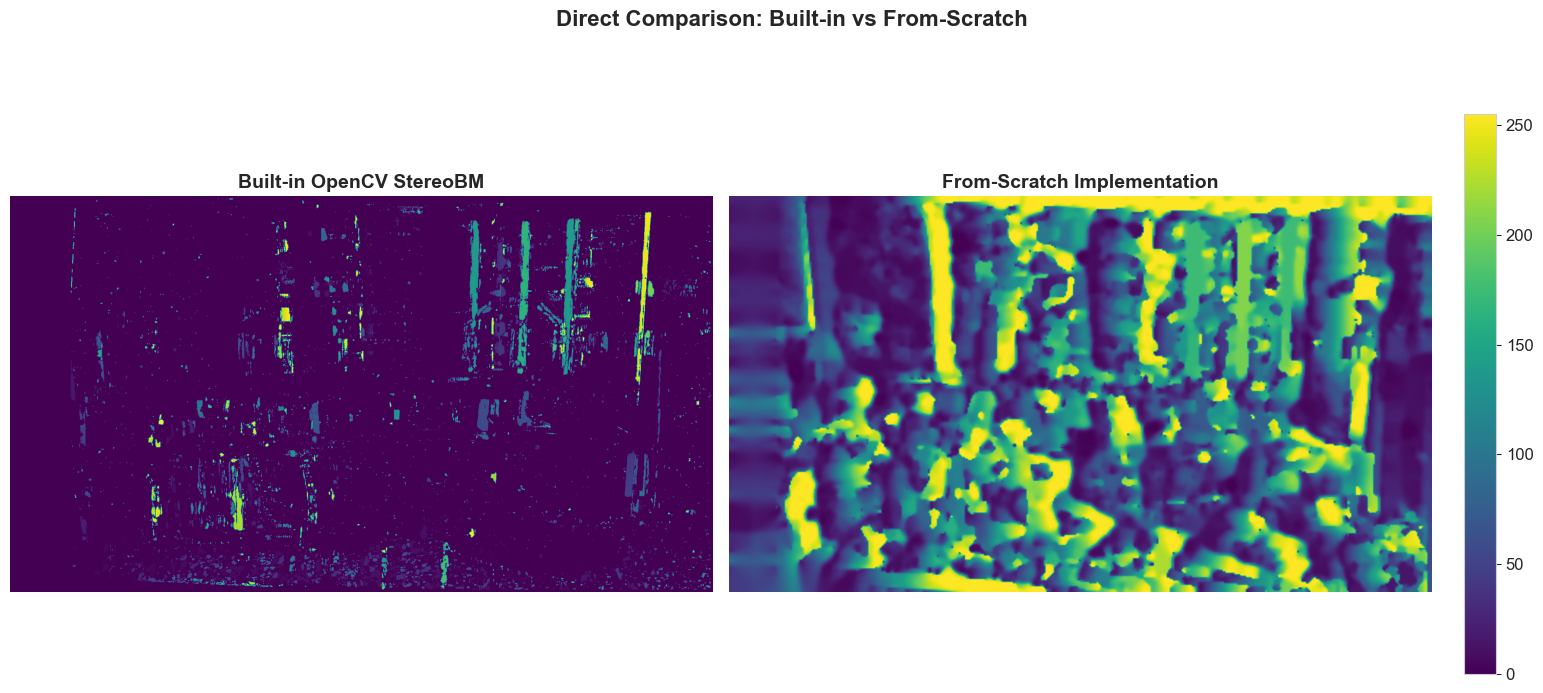

In [7]:
# Create a more direct comparison between the methods
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# OpenCV built-in method
im0 = axes[0].imshow(disp_builtin_norm, cmap='viridis')
axes[0].set_title('Built-in OpenCV StereoBM', fontsize=14, fontweight='bold')
axes[0].axis('off')

# From-scratch method
im1 = axes[1].imshow(disp_scratch_norm, cmap='viridis')
axes[1].set_title('From-Scratch Implementation', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Add colorbar
plt.tight_layout()
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im0, cax=cbar_ax)

plt.suptitle('Direct Comparison: Built-in vs From-Scratch', fontsize=16, fontweight='bold')
plt.show()
